# Transform parameters

A positive parameter can be represented by an unconstrained source while the
likelihood still receives its positive value. Use a bijection when you want to
preserve a prior already defined on the positive scale.

## Keep positive values

Starting with `model` from {doc}`tutorials/notebooks/11-model-building`, copy
it and transform its variance:

In [1]:
import jax
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

In [2]:
# Python cell fragment: imports are visible in each guide.
x_data = jnp.linspace(-1.0, 1.0, 80)
y_data = 1.0 + 2.0 * x_data + 0.7 * jax.random.normal(jax.random.key(42), (80,))

prior_scale = lsl.Var.new_value(2.5, name="prior_scale")
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=prior_scale),
    name="beta",
)
variance = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.LogNormal, loc=0.0, scale=0.5),
    name="variance",
)
x = lsl.Var.new_obs(x_data, name="x")

mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)
sigma = lsl.Var.new_calc(jnp.sqrt, variance, name="sigma")
y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y)

# Match the tutorial after its reactive update.
beta.value = jnp.array([1.0, 2.0])


In [3]:
transformed = model.copy()
variance = transformed.vars["variance"]

variance.biject(tfb.Exp(), name="log_variance")
log_variance = variance.bijected_var

In [4]:
(log_variance.name, float(log_variance.value), float(variance.value))

('log_variance', 0.0, 1.0)

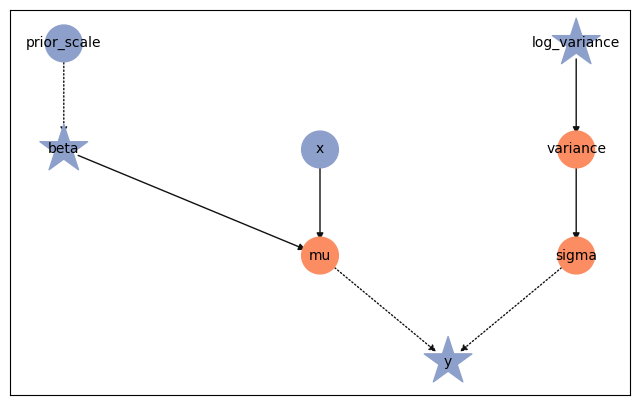

In [5]:
transformed.plot(width=8, height=5, legend=False)

The new strong parameter is `log_variance`. The original `variance` is now
weak and calculates `exp(log_variance)`. The exponential bijector's forward
direction goes from the unconstrained value to the positive value; its inverse
computes the initial log variance. The graph gains that value dependency. Its colors and edges follow the
key in the first tutorial.

{meth}`biject <liesel.model.Var.biject>` returns the original variable, which is useful for chaining. Read
{attr}`.bijected_var <liesel.model.Var.bijected_var>` to obtain the new parameter. {meth}`~liesel.model.Var.transform`
returns the transformed variable instead. `biject("auto")` selects the
distribution's default event-space bijector; an explicit bijector makes your
choice visible.

## Preserve the density

The prior moves to the unconstrained source and includes the change-of-variables
Jacobian. If the original prior is on variance {math}`v` and {math}`u=\log(v)`,
the transformed log density is {math}`\log p(\exp(u)) + u`.
The parameter flag moves to the source as well.

By comparison, `new_calc(jnp.exp, log_variance)` only creates a calculation.
A normal prior placed directly on `log_variance` defines a log-normal prior
on variance; it does not automatically transform an arbitrary prior on variance.
The second tutorial uses this direct modeling choice for a log-scale predictor.

Density modes depend on the parameterization. Even with the correct Jacobian,
optimizing the transformed density need not give the transform of the original
density's mode.

## Choose parameters

For an existing distribution, {meth}`~liesel.model.Dist.biject_parameters` can
transform its strong parameter inputs. For example, this selects the scale
input of a normal likelihood:

In [6]:
scale = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.LogNormal, loc=0.0, scale=0.5),
    name="scale",
)

likelihood = lsl.Dist(tfd.Normal, loc=0.0, scale=scale)

likelihood.biject_parameters({"scale": tfb.Exp()});

In [7]:
scale.bijected_var.name

'h(scale)'

These keys name distribution arguments, not model variables. For precise control
over the source name and its inference configuration, use {meth}`Var.biject <liesel.model.Var.biject>`.

## Set up inference

If a variable already has inference settings, supply settings for the new source
or explicitly drop the old ones with `inference="drop"`. For an untransformed
variance prepared for NUTS, the corresponding call is:

In [8]:
prepared = model.copy()
prepared.vars["variance"].biject(
    tfb.Exp(),
    name="log_variance",
    inference=gs.MCMCSpec(gs.NUTSKernel),
);

Sample or optimize `log_variance` and interpret the back-transformed
`variance`. Configure the other parameters too before running inference.
See {doc}`tutorials/md/01c-transform` for a complete MCMC example and
{doc}`optimizer-customization` for parameter selection in optimization.